# 07 — Treinamento do Modelo Random Forest

Treina e exporta o modelo que alimenta o assistente de jogada.

| Etapa | O que faz |
|---|---|
| 1 | Imports e caminhos |
| 2 | Carrega o `dataset.csv` e gera labels por dificuldade geométrica |
| 3 | Treina o Random Forest e avalia a acurácia |
| 4 | Analisa importância das features e salva `models/random_forest_jogada.pkl` |

**Entrada:** `data/dataset.csv`  
**Saída:** `models/random_forest_jogada.pkl`

## 1 — Imports e Caminhos

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

CAMINHO_CSV     = os.path.join("..", "data", "dataset.csv")
CAMINHO_MODELOS = os.path.join("..", "models")

TIPO_PARA_NUM = {"lisa": 1.0, "listrada": -1.0, "preta": 2.0}

os.makedirs(CAMINHO_MODELOS, exist_ok=True)
print("Caminhos configurados.")

Caminhos configurados.


## 2 — Carregar os Dados e Gerar Labels

O `dataset.csv` tem os vetores geométricos de cada frame. Como não existe label manual de "melhor jogada", geramos automaticamente usando uma **heurística de dificuldade física**:

```
dificuldade = ang_corte + (dist_cac * 0.5)
```

- **`ang_corte`** — o ângulo de corte é o fator dominante. Elevado ao quadrado porque dificuldade cresce de forma superlinear: um corte de 60° é mais difícil de um corte de 30°.
- **`dist_cacapa × 0.5`** — distância da bola até a caçapa mais próxima. Importa, mas menos que os outro fator.

In [2]:
try:
    df = pd.read_csv(CAMINHO_CSV)
    print(f"Dataset carregado: {df.shape[0]} frames, {df.shape[1]} colunas.")
except FileNotFoundError:
    print(f"[ERRO] {CAMINHO_CSV} não encontrado. Rode o 04_feature_eng.ipynb primeiro.")
    df = None

if df is not None and "alvo_bola" not in df.columns:
    print("Gerando labels automaticamente...")
    labels = []

    for _, row in df.iterrows():
        melhor_idx  = None
        menor_dific = float("inf")

        for i in range(1, 16):
            tipo      = row[f"b{i}_tipo"]
            ang_corte = row[f"b{i}_ang_corte"]
            dist_cac  = row[f"b{i}_dist_cacapa"]
            dist_br   = row[f"b{i}_dist_branca"]

            if tipo == 0.0 and ang_corte == 0.0 and dist_cac == 0.0:
                continue

            dificuldade = ang_corte + (dist_cac * 0.5)

            if dificuldade < menor_dific:
                menor_dific = dificuldade
                melhor_idx  = i

        labels.append(melhor_idx if melhor_idx is not None else 1)

    df["alvo_bola"] = labels
    print(f"Labels gerados. Distribuição:\n{pd.Series(labels).value_counts().sort_index()}")

Dataset carregado: 53 frames, 107 colunas.
Gerando labels automaticamente...
Labels gerados. Distribuição:
1     8
2     4
3     2
4     5
5     1
6     6
7     6
8     3
9     4
10    6
11    2
12    2
13    2
14    1
15    1
Name: count, dtype: int64


/tmp/ipykernel_1534325/2075024982.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["alvo_bola"] = labels


## 3 — Treinamento do Random Forest

Separamos 80% dos dados para treino e 20% para teste. `class_weight="balanced"` compensa a distribuição desigual de labels (algumas bolas viram alvo com mais frequência que outras).

In [3]:
if df is not None:
    feature_cols = [c for c in df.columns if c != "alvo_bola"]
    X = df[feature_cols]
    y = df["alvo_bola"]

    if len(df) > 5:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
    else:
        print("[AVISO] Poucos dados — treinando e testando no mesmo conjunto.")
        X_train, X_test, y_train, y_test = X, X, y, y

    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
    )
    rf_model.fit(X_train, y_train)

    acuracia = accuracy_score(y_test, rf_model.predict(X_test))
    print(f"Acurácia no conjunto de teste: {acuracia * 100:.2f}%")
    print()
    print(classification_report(y_test, rf_model.predict(X_test)))

Acurácia no conjunto de teste: 18.18%

              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       1.00      1.00      1.00         1

    accuracy                           0.18        11
   macro avg       0.17      0.12      0.14        11
weighted avg       0.27      0.18      0.21        11



/home/juliana/Projects/UFSC/visao/SinucaVision/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juliana/Projects/UFSC/visao/SinucaVision/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juliana/Projects/UFSC/visao/SinucaVision/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

## 4 — Importância das Features e Exportação do Modelo

O Random Forest revela quais variáveis geométricas foram mais consultadas. Com a heurística, `ang_corte` e `dist_branca` devem aparecer entre as mais importantes.

O modelo é salvo com `feature_names_in_` embutido, então o notebook de inferência lê a ordem correta de colunas diretamente do `.pkl`, sem precisar redefini-la.

Top 10 features mais importantes:
       Feature  Importância
  b7_ang_corte     0.029626
 b6_ang_branca     0.027698
  b6_ang_corte     0.023147
  b2_ang_corte     0.022216
          b2_x     0.017404
  b1_ang_corte     0.016816
 b3_ang_branca     0.016745
  b3_ang_corte     0.016124
b6_dist_branca     0.016104
 b5_ang_branca     0.015984


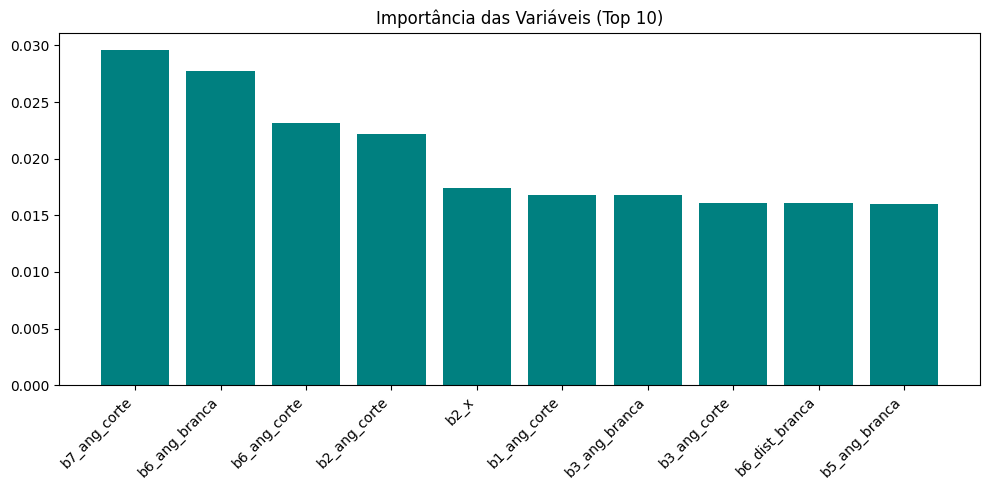

Modelo salvo em: ../models/random_forest_jogada.pkl


In [4]:
if df is not None:
    df_imp = pd.DataFrame({
        "Feature":     X.columns,
        "Importância": rf_model.feature_importances_,
    }).sort_values("Importância", ascending=False)

    print("Top 10 features mais importantes:")
    print(df_imp.head(10).to_string(index=False))

    plt.figure(figsize=(10, 5))
    plt.bar(df_imp["Feature"].head(10), df_imp["Importância"].head(10), color="teal")
    plt.xticks(rotation=45, ha="right")
    plt.title("Importância das Variáveis (Top 10)")
    plt.tight_layout()
    plt.show()

    caminho_pkl = os.path.join(CAMINHO_MODELOS, "random_forest_jogada.pkl")
    joblib.dump(rf_model, caminho_pkl)
    print(f"Modelo salvo em: {caminho_pkl}")